<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC640 - Data Presentation and Visualization

## **Name:** Tim Hollis

## **Assignment:** Term Project Milestone 2 

## **Date:** June 30, 2026

---

**Reference**

U.S. Department of Labor, Women's Bureau. (2024). *National database of childcare prices* [Data set]. https://www.dol.gov/agencies/wb/topics/featured-childcare

</div>

### **Initial Setup**

In [1]:
# Libraries
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker
from IPython.display import display, Markdown, HTML

# Visualization formatting
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'sans-serif'

display(HTML('''
<style>
    div.output_subarea { page-break-inside: avoid; }
    div.jp-MarkdownOutput { page-break-inside: avoid; }
    div.cell { page-break-inside: avoid; }
</style>
'''))

# Colorblind-safe project palette (carried over from Milestone 1)
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#F2F2F2'
DARK_GRAY = '#333333'
PROJECT_PALETTE = [ROYAL_BLUE, PURPLE, FOREST_GREEN, AMBER]

print('✅ Setup complete - palette and formatting ready for storyboard mock-ups')

✅ Setup complete - palette and formatting ready for storyboard mock-ups


<h2 style="margin-top:0.75in;">Overview</h2> 

This milestone builds on the story established in Milestone 1: childcare in Texas fails the federal 
government's own affordability standard almost everywhere, the burden has grown over the past decade, 
and the household-level math now forces working mothers to weigh whether employment still pays once 
care is factored in. The audience is Texas state legislators and staff, policy literate but not data 
literate and carrying some fiscal skepticism toward new spending, and my role is a constituent data 
analyst presenting verified federal data from the National Database of Childcare Prices (U.S. 
Department of Labor, Women's Bureau, 2024). Three mediums carry this story to that audience: a 
PowerPoint deck for a scheduled briefing, a Power BI dashboard for self-serve district lookups, and 
a one-page infographic as a memorable leave-behind. The storyboards and mock-ups that follow lay out 
the structure and visual plan for each before real data is layered in during the next milestone.

## Medium 1: PowerPoint Briefing Deck Storyboard

**Audience:** Texas state legislators and legislative staff. They are policy literate but not data 
literate, so the deck needs to translate statistics into plain claims rather than assume familiarity 
with the dataset. My role is a constituent data analyst presenting verified federal data, which gives 
me credibility without requiring an institutional affiliation. The audience's likely bias is fiscal 
skepticism toward new spending, so the deck has to earn the ask rather than simply state it.

**Plan:** The deck opens by establishing the federal affordability standard so legislators have a 
shared benchmark before seeing any numbers, since a percentage means nothing without context for 
what counts as reasonable. From there it walks through the affordability gap, the decade trend, and 
the second-earner math in that order, building urgency step by step before the ask ever appears. A 
Texas and Bexar County spotlight makes the data feel local and personal rather than a national 
abstraction that a legislator can set aside. A reframing slide comes right before the funding request 
and exists specifically to preempt the fiscal-skepticism bias, positioning childcare as workforce 
infrastructure rather than welfare spending, since that reframe is what determines whether the ask 
gets heard or dismissed. The deck closes with one specific, actionable call to action: expand state 
childcare subsidy funding and raise the income-eligibility ceiling. Each slide is built around a 
single idea paired with a single visual, since legislative staff review decks quickly between 
meetings and rarely sit through dense paragraphs of text. Slide titles are written as complete claims 
rather than neutral topic labels, so the narrative arc holds together even if a slide is pulled out 
and read in isolation, which is common when staff forward individual slides internally. The closing 
slide leaves my name and contact information to reinforce the constituent-analyst credibility angle 
established in Milestone 1 and to invite follow-up questions.

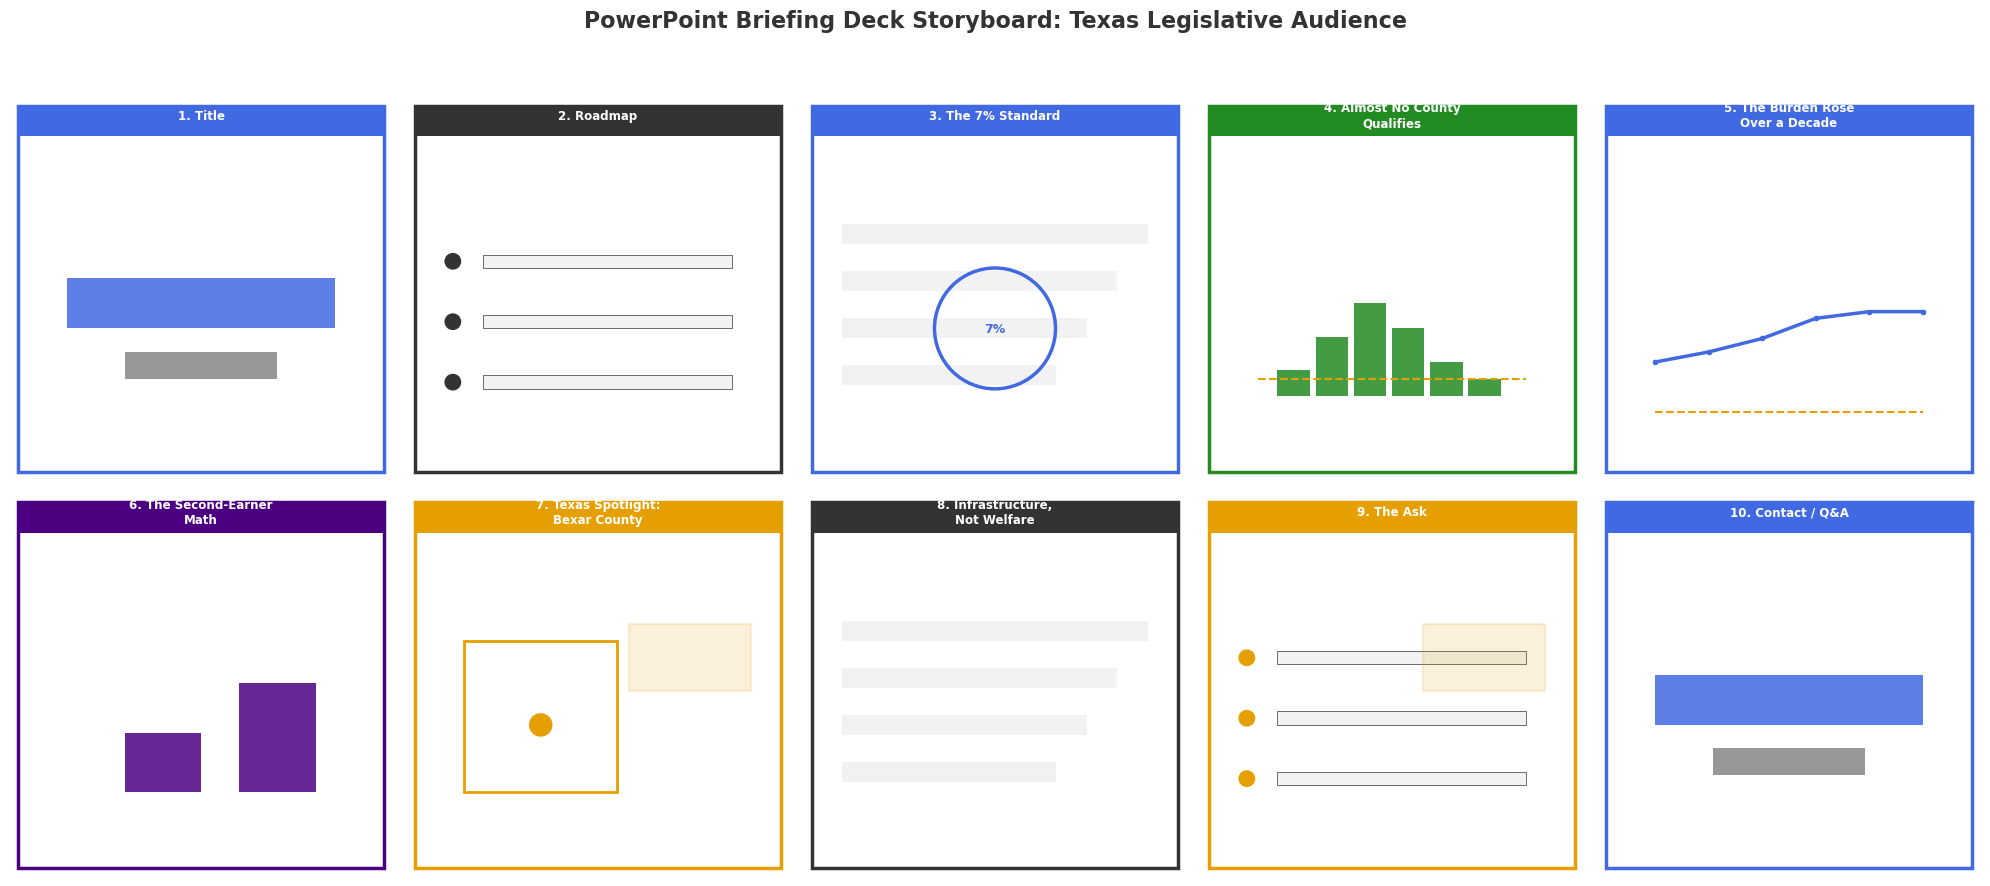

✅ PowerPoint storyboard mock-up complete: 10 slides mapped to the legislative narrative arc


In [2]:
# Slide plan: title, accent color, and a short list of content block types
slides = [
    ('1. Title', ROYAL_BLUE, ['title_text']),
    ('2. Roadmap', DARK_GRAY, ['bullets']),
    ('3. The 7% Standard', ROYAL_BLUE, ['text_block', 'icon']),
    ('4. Almost No County\nQualifies', FOREST_GREEN, ['chart_hist']),
    ('5. The Burden Rose\nOver a Decade', ROYAL_BLUE, ['chart_line']),
    ('6. The Second-Earner\nMath', PURPLE, ['chart_bar']),
    ('7. Texas Spotlight:\nBexar County', AMBER, ['map', 'callout']),
    ('8. Infrastructure,\nNot Welfare', DARK_GRAY, ['text_block']),
    ('9. The Ask', AMBER, ['bullets', 'callout']),
    ('10. Contact / Q&A', ROYAL_BLUE, ['title_text']),
]


def draw_content_block(ax, block_type, x, y, w, h, accent):
    '''Draw a placeholder shape inside a slide thumbnail representing a content type'''
    if block_type == 'title_text':
        ax.add_patch(
            patches.Rectangle(
                (x + w * 0.15,
                 y + h * 0.45),
                w * 0.7,
                h * 0.15,
                facecolor=accent,
                alpha=0.85))
        ax.add_patch(
            patches.Rectangle(
                (x + w * 0.3,
                 y + h * 0.3),
                w * 0.4,
                h * 0.08,
                facecolor=DARK_GRAY,
                alpha=0.5))
    elif block_type == 'bullets':
        for i in range(3):
            by = y + h * 0.65 - i * h * 0.18
            ax.add_patch(
                patches.Circle(
                    (x + w * 0.12,
                     by),
                    h * 0.025,
                    facecolor=accent))
            ax.add_patch(
                patches.Rectangle(
                    (x + w * 0.2,
                     by - h * 0.02),
                    w * 0.65,
                    h * 0.04,
                    facecolor=LIGHT_GRAY,
                    edgecolor=DARK_GRAY,
                    linewidth=0.5))
    elif block_type == 'text_block':
        for i in range(4):
            by = y + h * 0.7 - i * h * 0.14
            ax.add_patch(patches.Rectangle((x + w * 0.1,
                                            by),
                                           w * (0.8 - i * 0.08),
                                           h * 0.06,
                                           facecolor=LIGHT_GRAY,
                                           edgecolor='none'))
    elif block_type == 'icon':
        ax.add_patch(
            patches.Circle(
                (x + w * 0.5,
                 y + h * 0.45),
                h * 0.18,
                facecolor='none',
                edgecolor=accent,
                linewidth=2.5))
        ax.text(x + w * 0.5, y + h * 0.45, '7%', ha='center', va='center',
                fontsize=9, fontweight='bold', color=accent)
    elif block_type == 'chart_hist':
        bar_heights = [0.15, 0.35, 0.55, 0.4, 0.2, 0.1]
        bw = w * 0.6 / len(bar_heights)
        for i, bh in enumerate(bar_heights):
            ax.add_patch(
                patches.Rectangle(
                    (x + w * 0.2 + i * bw,
                     y + h * 0.25),
                    bw * 0.85,
                    bh * h * 0.5,
                    facecolor=accent,
                    alpha=0.85))
        ax.plot([x + w * 0.15, x + w * 0.85], [y + h * 0.3, y + h * 0.3],
                color=AMBER, linestyle='--', linewidth=1.5)
    elif block_type == 'chart_line':
        xs = [x + w * 0.15 + i * (w * 0.7 / 5) for i in range(6)]
        ys = [
            y + h * 0.35,
            y + h * 0.38,
            y + h * 0.42,
            y + h * 0.48,
            y + h * 0.5,
            y + h * 0.5]
        ax.plot(xs, ys, color=accent, linewidth=2.5, marker='o', markersize=3)
        ax.plot([x + w * 0.15, x + w * 0.85], [y + h * 0.2, y + h * 0.2],
                color=AMBER, linestyle='--', linewidth=1.5)
    elif block_type == 'chart_bar':
        bars = [0.35, 0.65]
        bw = w * 0.2
        for i, bh in enumerate(bars):
            ax.add_patch(patches.Rectangle((x + w * 0.3 + i * (bw + w * 0.1),
                         y + h * 0.25), bw, bh * h * 0.5, facecolor=accent, alpha=0.85))
    elif block_type == 'map':
        ax.add_patch(
            patches.Rectangle(
                (x + w * 0.15,
                 y + h * 0.25),
                w * 0.4,
                h * 0.45,
                facecolor='none',
                edgecolor=accent,
                linewidth=2))
        ax.add_patch(
            patches.Circle(
                (x + w * 0.35,
                 y + h * 0.45),
                h * 0.035,
                facecolor=accent))
    elif block_type == 'callout':
        ax.add_patch(
            patches.Rectangle(
                (x + w * 0.58,
                 y + h * 0.55),
                w * 0.32,
                h * 0.2,
                facecolor=accent,
                alpha=0.15,
                edgecolor=accent,
                linewidth=1.5))


fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('PowerPoint Briefing Deck Storyboard: Texas Legislative Audience',
             fontsize=16, fontweight='bold', color=DARK_GRAY, y=0.98)

for ax, (title, accent, blocks) in zip(axes.flat, slides):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor('white')

    frame = patches.Rectangle((0.02, 0.02), 0.96, 0.96, facecolor='white',
                              edgecolor=accent, linewidth=2.5)
    ax.add_patch(frame)
    ax.add_patch(patches.Rectangle((0.02, 0.9), 0.96, 0.08, facecolor=accent))

    for block in blocks:
        draw_content_block(ax, block, 0, 0, 1, 0.88, accent)

    ax.text(0.5, 0.955, title, ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='white')

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
print('✅ PowerPoint storyboard mock-up complete: 10 slides mapped to the legislative narrative arc')

<h2 style="margin-top:0.75in;">Medium 2: Power BI Dashboard Mock-up</h2> 

**Audience:** The same Texas legislators and staff from the briefing deck, but in a self-serve 
context. After the initial pitch, a staffer wants to look up the numbers for their own district 
without emailing me back and waiting for a reply, so the dashboard has to function without me in 
the room to explain it.

**Plan:** The dashboard leads with a KPI strip of large, unmissable numbers, since this audience 
scans rather than analyzes, and the headline stats are what get repeated in a hearing, a memo, or a 
constituent letter. A county selector lets staff filter to their own district, which is the entire 
reason the dashboard exists as a separate medium from the static deck; without that interactivity it 
would just be a worse version of the presentation. The trend line and second-earner bar chart 
intentionally mirror the visuals used in the deck rather than introducing new chart types, so a 
staffer who already saw the presentation recognizes the story immediately instead of having to learn 
a new visual language. A persistent benchmark footer keeps the HHS seven percent affordability line 
visible at all times, since that single number is the credibility anchor for the entire argument and 
should never scroll out of view. I deliberately avoided a dense grid of small multiples or a raw 
drill-down table, since a confident but non-data-literate user should be able to select their county 
and understand the finding within a few seconds, not need a tutorial or a sit-down walkthrough. The 
county selector will default to a statewide view rather than loading empty on first open, and once 
real data is added, hovering over a county will surface its exact income-share percentage and dollar 
figures as supporting detail beneath the headline numbers, giving staff a path to more depth without 
forcing it on them.

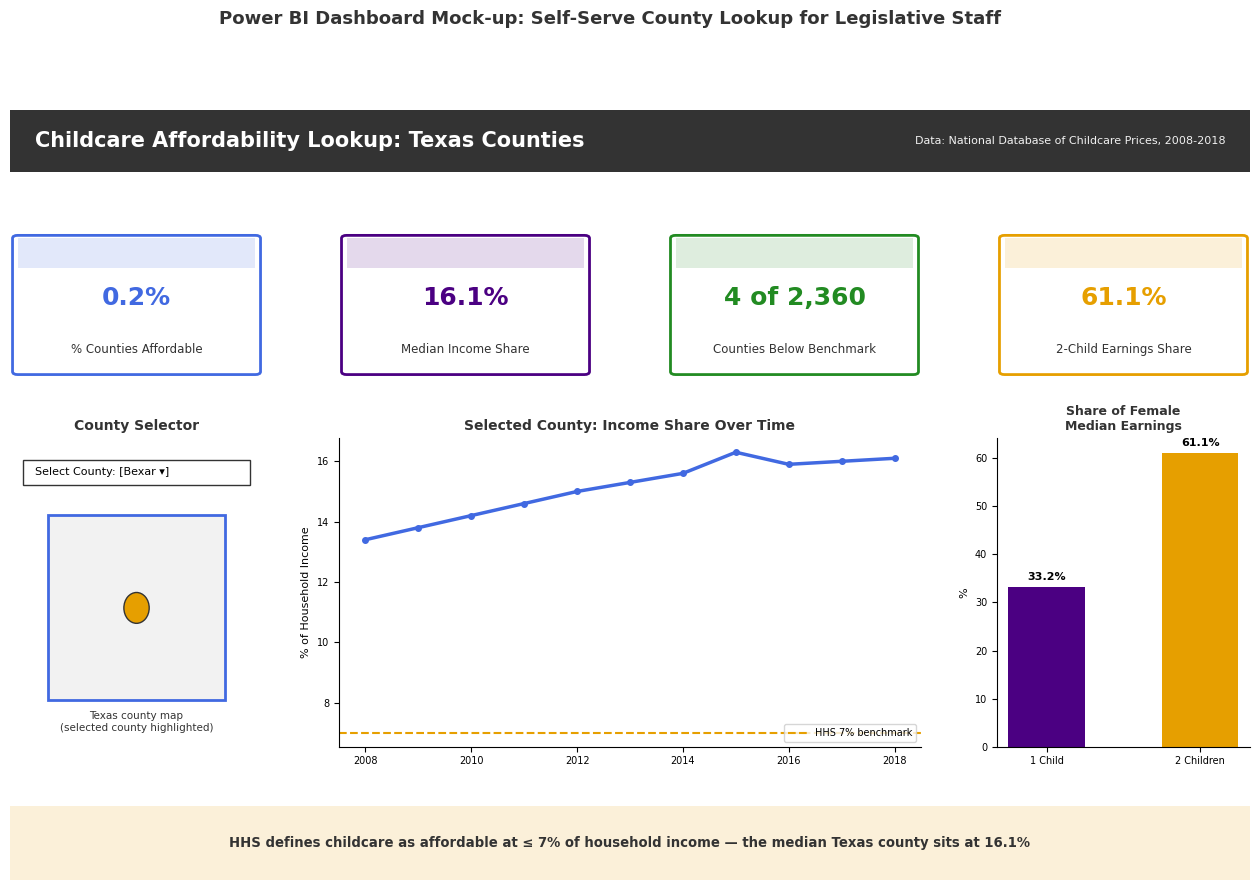

✅ Power BI dashboard mock-up complete: KPI strip, county selector, trend, and earnings comparison


In [3]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    4,
    4,
    height_ratios=[
        0.5,
        1.2,
        2.5,
        0.6],
    hspace=0.4,
    wspace=0.3)

# Title bar
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_xlim(0, 1)
ax_title.set_ylim(0, 1)
ax_title.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=DARK_GRAY))
ax_title.text(
    0.02,
    0.5,
    'Childcare Affordability Lookup: Texas Counties',
    ha='left',
    va='center',
    fontsize=15,
    fontweight='bold',
    color='white')
ax_title.text(
    0.98,
    0.5,
    'Data: National Database of Childcare Prices, 2008-2018',
    ha='right',
    va='center',
    fontsize=8,
    color=LIGHT_GRAY)
ax_title.axis('off')

# KPI strip
kpis = [
    ('% Counties Affordable', '0.2%', ROYAL_BLUE),
    ('Median Income Share', '16.1%', PURPLE),
    ('Counties Below Benchmark', '4 of 2,360', FOREST_GREEN),
    ('2-Child Earnings Share', '61.1%', AMBER),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, i])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(
        patches.FancyBboxPatch(
            (0.03,
             0.05),
            0.94,
            0.9,
            boxstyle='round,pad=0.02',
            facecolor='white',
            edgecolor=color,
            linewidth=2))
    ax.add_patch(
        patches.Rectangle(
            (0.03,
             0.75),
            0.94,
            0.2,
            facecolor=color,
            alpha=0.15))
    ax.text(
        0.5,
        0.55,
        value,
        ha='center',
        va='center',
        fontsize=18,
        fontweight='bold',
        color=color)
    ax.text(
        0.5,
        0.2,
        label,
        ha='center',
        va='center',
        fontsize=8.5,
        color=DARK_GRAY,
        wrap=True)
    ax.axis('off')

# County selector + map placeholder (left)
ax_selector = fig.add_subplot(gs[2, 0])
ax_selector.set_xlim(0, 1)
ax_selector.set_ylim(0, 1)
ax_selector.add_patch(
    patches.Rectangle(
        (0.05,
         0.85),
        0.9,
        0.08,
        facecolor='white',
        edgecolor=DARK_GRAY,
        linewidth=1))
ax_selector.text(
    0.1,
    0.89,
    'Select County: [Bexar \u25be]',
    ha='left',
    va='center',
    fontsize=8)
ax_selector.add_patch(
    patches.Rectangle(
        (0.15,
         0.15),
        0.7,
        0.6,
        facecolor=LIGHT_GRAY,
        edgecolor=ROYAL_BLUE,
        linewidth=2))
ax_selector.add_patch(
    patches.Circle(
        (0.5,
         0.45),
        0.05,
        facecolor=AMBER,
        edgecolor=DARK_GRAY))
ax_selector.text(0.5, 0.08, 'Texas county map\n(selected county highlighted)',
                 ha='center', va='center', fontsize=7.5, color=DARK_GRAY)
ax_selector.set_title(
    'County Selector',
    fontsize=10,
    fontweight='bold',
    color=DARK_GRAY)
ax_selector.axis('off')

# Trend line (middle, spans 2 cols)
ax_trend = fig.add_subplot(gs[2, 1:3])
years = list(range(2008, 2019))
values = [13.4, 13.8, 14.2, 14.6, 15.0, 15.3, 15.6, 16.3, 15.9, 16.0, 16.1]
ax_trend.plot(
    years,
    values,
    color=ROYAL_BLUE,
    linewidth=2.5,
    marker='o',
    markersize=4)
ax_trend.axhline(
    7,
    color=AMBER,
    linestyle='--',
    linewidth=1.5,
    label='HHS 7% benchmark')
ax_trend.set_title(
    'Selected County: Income Share Over Time',
    fontsize=10,
    fontweight='bold',
    color=DARK_GRAY)
ax_trend.set_ylabel('% of Household Income', fontsize=8)
ax_trend.tick_params(labelsize=7)
ax_trend.legend(fontsize=7, loc='lower right')
ax_trend.spines['top'].set_visible(False)
ax_trend.spines['right'].set_visible(False)

# Second-earner bar chart (right)
ax_bar = fig.add_subplot(gs[2, 3])
categories = ['1 Child', '2 Children']
bar_values = [33.2, 61.1]
ax_bar.bar(categories, bar_values, color=[PURPLE, AMBER], width=0.5)
ax_bar.set_title(
    'Share of Female\nMedian Earnings',
    fontsize=9,
    fontweight='bold',
    color=DARK_GRAY)
ax_bar.set_ylabel('%', fontsize=8)
ax_bar.tick_params(labelsize=7)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
for i, v in enumerate(bar_values):
    ax_bar.text(
        i,
        v + 1.5,
        f'{v}%',
        ha='center',
        fontsize=8,
        fontweight='bold')

# Benchmark footer strip
ax_footer = fig.add_subplot(gs[3, :])
ax_footer.set_xlim(0, 1)
ax_footer.set_ylim(0, 1)
ax_footer.add_patch(patches.Rectangle(
    (0, 0), 1, 1, facecolor=AMBER, alpha=0.15))
ax_footer.text(
    0.5,
    0.5,
    'HHS defines childcare as affordable at \u2264 7% of household income \u2014 the median Texas county sits at 16.1%',
    ha='center',
    va='center',
    fontsize=9.5,
    color=DARK_GRAY,
    fontweight='bold')
ax_footer.axis('off')

fig.suptitle(
    'Power BI Dashboard Mock-up: Self-Serve County Lookup for Legislative Staff',
    fontsize=13,
    fontweight='bold',
    color=DARK_GRAY,
    y=0.98)

plt.show()
print('✅ Power BI dashboard mock-up complete: KPI strip, county selector, trend, and earnings comparison')

<h2 style="margin-top:0.75in;">Medium 3: Infographic Mock-up</h2> 

**Audience:** The same Texas legislators and staff, but this is the artifact that outlives the 
meeting itself: a printed leave-behind and a shareable graphic that staff can forward without opening 
a deck or a dashboard. It may also reach a wider circle than the other two mediums, since 
infographics tend to travel further than presentations once they leave the original meeting.

**Plan:** The infographic is built as a single vertical page, since it needs to function both printed 
on paper and as a standalone image file with no clicking, no scrolling, and no software required to 
view it. It leads with one hero statistic, four of 2,360 counties, because a leave-behind lives or 
dies on whether a single number sticks in someone's memory after the meeting ends and the deck is 
forgotten. Three supporting stat blocks sit below it and round out the argument without requiring the 
reader to interpret a chart, since a leave-behind typically gets a few seconds of attention rather 
than a full walkthrough with someone narrating it. A simplified version of the decade trend line 
reinforces that this is a worsening problem rather than a static condition, which matters for the 
urgency of the ask. The bottom third of the page is a compact call-to-action strip stating the 
specific request, expanding subsidy funding and raising the income-eligibility ceiling, paired with 
my name and role as a constituent analyst for credibility. Color is used sparingly and stays 
consistent with the other two mediums, so a reader who already saw the deck or the dashboard 
recognizes the same story here rather than encountering what feels like a fourth, disconnected 
argument. Unlike the dashboard, there is no interactivity and no raw data table anywhere on the page; 
everything is pre-digested into the four numbers that matter most to this specific audience.

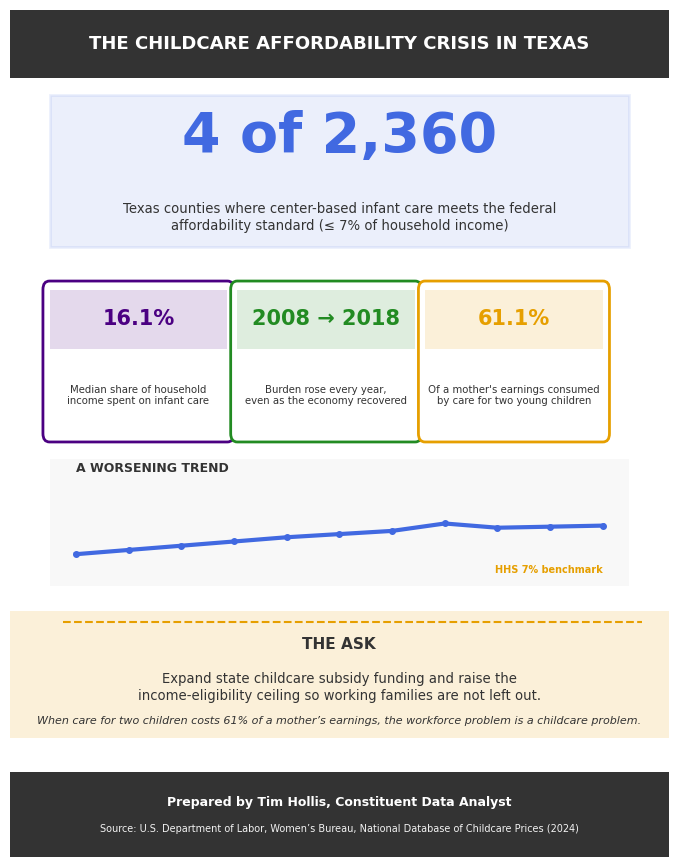

✅ Infographic mock-up complete: hero stat, three supporting stats, trend, and call to action


In [4]:
fig, ax = plt.subplots(figsize=(8.5, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Header band
ax.add_patch(patches.Rectangle((0, 0.92), 1, 0.08, facecolor=DARK_GRAY))
ax.text(
    0.5,
    0.96,
    'THE CHILDCARE AFFORDABILITY CRISIS IN TEXAS',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    color='white')

# Hero stat
ax.add_patch(
    patches.Rectangle(
        (0.06,
         0.72),
        0.88,
        0.18,
        facecolor=ROYAL_BLUE,
        alpha=0.1,
        edgecolor=ROYAL_BLUE,
        linewidth=2))
ax.text(
    0.5,
    0.85,
    '4 of 2,360',
    ha='center',
    va='center',
    fontsize=40,
    fontweight='bold',
    color=ROYAL_BLUE)
ax.text(
    0.5,
    0.755,
    'Texas counties where center-based infant care meets the federal\naffordability standard (\u2264 7% of household income)',
    ha='center',
    va='center',
    fontsize=9.5,
    color=DARK_GRAY)

# Three supporting stat blocks
stats = [
    ('16.1%',
     'Median share of household\nincome spent on infant care',
     PURPLE),
    ('2008 \u2192 2018',
     'Burden rose every year,\neven as the economy recovered',
     FOREST_GREEN),
    ('61.1%',
     "Of a mother's earnings consumed\nby care for two young children",
     AMBER),
]
box_w = 0.27
for i, (stat, label, color) in enumerate(stats):
    x0 = 0.06 + i * (box_w + 0.015)
    ax.add_patch(
        patches.FancyBboxPatch(
            (x0,
             0.5),
            box_w,
            0.17,
            boxstyle='round,pad=0.01',
            facecolor='white',
            edgecolor=color,
            linewidth=2))
    ax.add_patch(
        patches.Rectangle(
            (x0,
             0.6),
            box_w,
            0.07,
            facecolor=color,
            alpha=0.15))
    ax.text(
        x0 + box_w / 2,
        0.635,
        stat,
        ha='center',
        va='center',
        fontsize=15,
        fontweight='bold',
        color=color)
    ax.text(
        x0 + box_w / 2,
        0.545,
        label,
        ha='center',
        va='center',
        fontsize=7.3,
        color=DARK_GRAY)

# Simplified trend sparkline
ax.add_patch(
    patches.Rectangle(
        (0.06,
         0.32),
        0.88,
        0.15,
        facecolor=LIGHT_GRAY,
        alpha=0.5))
years = list(range(2008, 2019))
values = [13.4, 13.8, 14.2, 14.6, 15.0, 15.3, 15.6, 16.3, 15.9, 16.0, 16.1]
x_vals = [0.1 + (yr - 2008) / 10 * 0.8 for yr in years]
y_vals = [0.34 + (v - 12) / 8 * 0.1 for v in values]
ax.plot(
    x_vals,
    y_vals,
    color=ROYAL_BLUE,
    linewidth=3,
    marker='o',
    markersize=4)
ax.axhline(0.34 + (7 - 12) / 8 * 0.1, color=AMBER,
           linestyle='--', linewidth=1.5, xmin=0.08, xmax=0.96)
ax.text(
    0.1,
    0.455,
    'A WORSENING TREND',
    fontsize=9,
    fontweight='bold',
    color=DARK_GRAY)
ax.text(
    0.9,
    0.335,
    'HHS 7% benchmark',
    ha='right',
    fontsize=7,
    color=AMBER,
    fontweight='bold')

# Call to action strip
ax.add_patch(
    patches.Rectangle(
        (0,
         0.14),
        1,
        0.15,
        facecolor=AMBER,
        alpha=0.15))
ax.text(
    0.5,
    0.245,
    'THE ASK',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color=DARK_GRAY)
ax.text(
    0.5,
    0.2,
    'Expand state childcare subsidy funding and raise the\nincome-eligibility ceiling so working families are not left out.',
    ha='center',
    va='center',
    fontsize=9.5,
    color=DARK_GRAY)
ax.text(
    0.5,
    0.16,
    'When care for two children costs 61% of a mother\u2019s earnings, the workforce problem is a childcare problem.',
    ha='center',
    va='center',
    fontsize=8,
    style='italic',
    color=DARK_GRAY)

# Footer / credibility line
ax.add_patch(patches.Rectangle((0, 0), 1, 0.1, facecolor=DARK_GRAY))
ax.text(0.5, 0.06, 'Prepared by Tim Hollis, Constituent Data Analyst',
        ha='center', fontsize=9, color='white', fontweight='bold')
ax.text(
    0.5,
    0.03,
    'Source: U.S. Department of Labor, Women\u2019s Bureau, National Database of Childcare Prices (2024)',
    ha='center',
    fontsize=7,
    color=LIGHT_GRAY)

plt.show()
print('✅ Infographic mock-up complete: hero stat, three supporting stats, trend, and call to action')

<h2 style="margin-top:0.75in;">Conclusion: How the Three Mediums Work Together</h2> 

These three mediums are not three separate pitches, they are one story told at three different 
speeds. The PowerPoint deck is the slow version, walking a legislator through the affordability 
standard, the decade trend, and the second-earner math in sequence, building the case before the ask 
ever appears. The Power BI dashboard is the self-serve version, letting a staffer skip the narration 
and go straight to their own district's numbers once the initial argument has already landed. The 
infographic is the fast version, distilling everything down to four numbers a legislator can recall 
without opening anything at all. Each medium meets the audience at a different point in their 
attention span, from a scheduled briefing to a five-second scan of a leave-behind pinned to a 
bulletin board.

Keeping the palette, the benchmark line, and the core statistics identical across all three was a 
deliberate choice rather than a convenience. A legislative staffer who sees the deck in a meeting, 
later opens the dashboard to check their own county, and eventually finds the infographic in a stack 
of papers should recognize the same story each time rather than three competing arguments. That 
consistency is what turns three mediums into one campaign instead of three disconnected assets, and 
it is also what protects the credibility angle established in Milestone 1: a constituent analyst 
presenting the same verified numbers everywhere is more persuasive than one presenting different 
framings depending on the format. The next milestone will bring real data into each of these 
mock-ups, but the structure, hierarchy, and narrative arc built here should not need to change.

# Reflection

This week centered on transforming my childcare affordability narrative into three fully planned mediums: a PowerPoint briefing deck, a Power BI dashboard mock‑up, and a one‑page infographic. Building these storyboards forced me to think intentionally about how Texas legislators and staff actually process information. Instead of focusing on data analysis, I had to focus on communication design — how to make the federal affordability benchmark, the decade trend, and the second‑earner math immediately understandable to a policy‑literate but not data‑literate audience. The milestone helped me clarify the narrative arc and ensure that each medium supports the same story at different speeds: slow (deck), self‑serve (dashboard), and fast (infographic).

## Straightforward Aspects

- Structuring the PowerPoint storyboard was smooth because the legislative audience benefits from a linear, claim‑driven flow. The slide sequence naturally followed the argument: define the 7% benchmark, show the affordability gap, highlight the decade trend, explain the second‑earner math, and end with the ask.  
- The Power BI dashboard mock‑up came together easily since it intentionally mirrors the deck’s visuals. Designing the KPI strip, county selector, trend line, and earnings comparison felt intuitive for a self‑serve environment where staffers scan quickly.  
- The infographic layout was straightforward because the “hero stat + supporting stats + sparkline + call to action” structure fits how leave‑behinds are consumed. Keeping the palette and benchmark line consistent across mediums reinforced the unified campaign feel.

## Challenging Aspects

- Ensuring all three mediums told the same story without becoming repetitive required careful planning. Each needed a distinct purpose while still reinforcing the same core message.  
- Designing for a policy‑literate but not data‑literate audience meant simplifying visuals without oversimplifying the argument. Balancing clarity, credibility, and urgency was a challenge.  
- Creating mock‑ups without real data required thoughtful placeholders that still communicated hierarchy, intent, and visual structure. Making them look purposeful rather than generic took extra iteration.

